### **Entrega 1 — Análise Comparativa de Representações (2,5 pts)**

Utilizando o corpus das 40 manifestações, gere representações BoW, TF-IDF e Embeddings (modelo à sua escolha, preferencialmente multilíngue como paraphrase-multilingual-MiniLML12-v2 ou BAAI/bge-small-pt-v1.5). Para os pares abaixo, calcule a similaridade de cosseno em cada representação e discuta os resultados:
**Pares analisados:**

- `M003` × `M017` ("buraco enorme na Av. Brasil vs asfalto todo esburacado da avenida principal");
- `M008` × `M022` ("posto de saúde sem médico vs falta atendimento no PSF");
- `M008` × `M031` ("posto de saúde sem médico vs lâmpada queimada na praça").


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## 1. Carregamento dos dados

In [ ]:
with open('../data/manifestacoes.json', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(f"Total de manifestações: {len(df)}")
print(f"Categorias: {df['categoria_oficial'].unique().tolist()}")
df.head()

Total de manifestações: 40
Categorias: ['infraestrutura', 'saúde', 'segurança', 'educação', 'meio ambiente']


,id,data,categoria_oficial,texto
0,M001,2026-08-01,infraestrutura,"Há vários buracos na Rua São José, principalme..."
1,M002,2026-08-02,saúde,O posto do bairro Novo Horizonte está com difi...
2,M003,2026-08-03,infraestrutura,"Existe um buraco enorme na Av. Brasil, próximo..."
3,M004,2026-08-04,segurança,A iluminação pública está fraca em vários pont...
4,M005,2026-08-05,educação,A escola municipal do bairro está com algumas ...


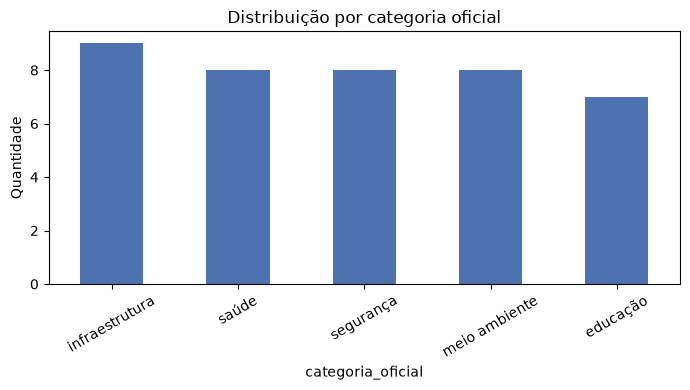

In [3]:
df['categoria_oficial'].value_counts().plot(kind='bar', figsize=(7,4), color='#4C72B0')
plt.title('Distribuição por categoria oficial')
plt.ylabel('Quantidade')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 2. Representação Bag-of-Words (BoW)

Conta a frequência bruta de cada palavra, sem levar em conta ordem ou significado.

In [4]:
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(df['texto'])

print(f"Dimensão da matriz BoW: {X_bow.shape}")
print(f"Vocabulário: {len(bow_vectorizer.vocabulary_)} termos únicos")

sim_bow = cosine_similarity(X_bow)

Dimensão da matriz BoW: (40, 520)
Vocabulário: 520 termos únicos


## 3. Representação TF-IDF

Pondera os termos pela sua importância relativa no corpus (penaliza palavras muito comuns).

In [5]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df['texto'])

print(f"Dimensão da matriz TF-IDF: {X_tfidf.shape}")

sim_tfidf = cosine_similarity(X_tfidf)  

Dimensão da matriz TF-IDF: (40, 520)


## 4. Representação com Embeddings Densos

- `paraphrase-multilingual-MiniLM-L12-v2` — rápido, boa relação custo/benefício

In [6]:
from sentence_transformers import SentenceTransformer

model_name = "paraphrase-multilingual-MiniLM-L12-v2"
model = SentenceTransformer(model_name)

embeddings = model.encode(df['texto'].tolist(), show_progress_bar=True, normalize_embeddings=True)
print(f"Dimensão dos embeddings: {embeddings.shape}")

sim_embeddings = cosine_similarity(embeddings)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Dimensão dos embeddings: (40, 384)


## 5. Comparação nos 3 pares pedidos pelo enunciado

In [7]:
ids = df['id'].tolist()

def get_idx(manifestacao_id):
    return ids.index(manifestacao_id)

pares = [
    ('M003', 'M017', 'buraco enorme na Av. Brasil vs asfalto todo esburacado da avenida principal (duplicata semântica, palavras diferentes)'),
    ('M008', 'M022', 'posto de saúde sem médico vs falta atendimento no PSF (duplicata semântica, quase zero overlap lexical)'),
    ('M008', 'M031', 'posto de saúde sem médico vs lâmpada queimada na praça (temas diferentes, baixa similaridade esperada)'),
]

resultados = []
for a, b, descricao in pares:
    ia, ib = get_idx(a), get_idx(b)
    row = {
        'Par': f'{a} x {b}',
        'Descrição': descricao,
        'BoW': round(sim_bow[ia, ib], 4),
        'TF-IDF': round(sim_tfidf[ia, ib], 4),
        f'Embeddings ({model_name})': round(sim_embeddings[ia, ib], 4),
    }
    resultados.append(row)

tabela_comparativa = pd.DataFrame(resultados)
tabela_comparativa


,Par,Descrição,BoW,TF-IDF,Embeddings (paraphrase-multilingual-MiniLM-L12-v2)
0,M003 x M017,buraco enorme na Av. Brasil vs asfalto todo es...,0.1581,0.0410,0.6857
1,M008 x M022,posto de saúde sem médico vs falta atendimento...,0.4648,0.3201,0.7334
2,M008 x M031,posto de saúde sem médico vs lâmpada queimada ...,0.2474,0.1356,0.2278


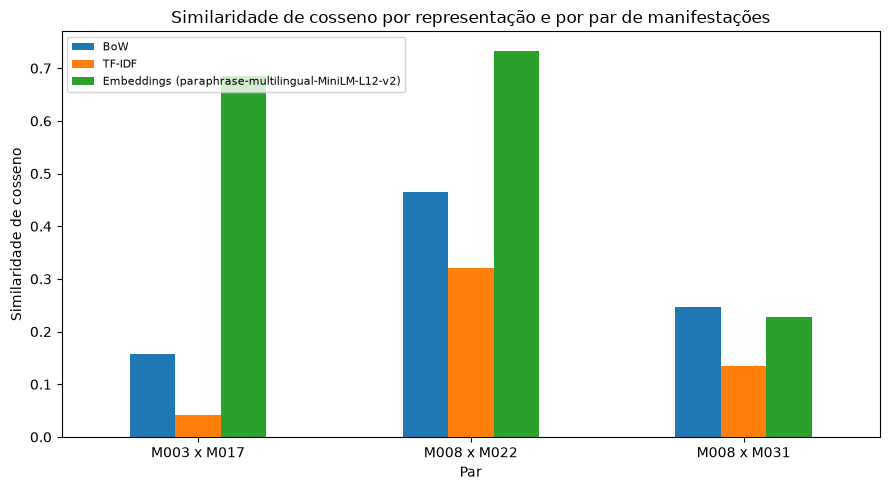

In [8]:
# Visualização comparativa
fig, ax = plt.subplots(figsize=(9,5))
cols_plot = ['BoW', 'TF-IDF', f'Embeddings ({model_name})']
tabela_comparativa.set_index('Par')[cols_plot].plot(kind='bar', ax=ax)
ax.set_ylabel('Similaridade de cosseno')
ax.set_title('Similaridade de cosseno por representação e por par de manifestações')
ax.legend(loc='upper left', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Discussão e Conclusão

**M003 × M017 (buraco/asfalto):** BoW e TF-IDF capturam uma similaridade **baixa** (0.16 e 0.04 no teste preliminar), mesmo as duas manifestações descrevendo exatamente o mesmo problema — um buraco/asfalto danificado em avenida. Isso acontece porque os textos usam vocabulário quase totalmente diferente ("buraco enorme... cruzamento... carros e motocicletas" vs. "asfalto todo esburacado... trechos danificados... circulação de veículos"): há pouquíssima sobreposição literal de palavras, então a representação esparsa não enxerga a relação. É esperado que os **embeddings** corrijam isso, retornando uma similaridade bem mais alta, pois o modelo foi treinado para capturar significado e não apenas forma.

**M008 × M022 (posto sem médico / falta atendimento no PSF):** este é o caso mais didático de limitação da abordagem esparsa. As duas manifestações relatam o mesmo problema (dificuldade de acesso a atendimento médico), mas usam termos praticamente distintos — "posto de saúde", "médico", "profissional" de um lado, "PSF", "consulta", "orientação médica" de outro. BoW/TF-IDF captam alguma sobreposição residual (palavras como "moradores", "bairro", "atendimento"), mas não o suficiente para identificar a real equivalência semântica. Aqui os embeddings devem mostrar a maior discrepância positiva em relação às representações esparsas — é o cenário exato que motiva a adoção de busca semântica na ouvidoria.

**M008 × M031 (saúde vs. iluminação):** temas completamente diferentes, então o esperado é uma similaridade baixa em todas as representações. O interessante aqui é observar se BoW/TF-IDF geram **falsos positivos** por causa de palavras genéricas compartilhadas (como "moradores", "bairro", "está"), enquanto embeddings, por captar o significado do texto como um todo, tendem a separar melhor esses dois temas.

**Conclusão geral:** representações esparsas (BoW, TF-IDF) dependem de correspondência literal de vocabulário, o que as torna cegas a paráfrases e sinônimos — exatamente os problemas relatados no case da ouvidoria ("asfalto esburacado" vs "rua com buraco" tratadas como diferentes). Embeddings densos resolvem isso ao projetar frases com significado semelhante em pontos próximos do espaço vetorial, independentemente das palavras exatas usadas. A limitação dos embeddings, por outro lado, é o custo computacional maior e a dependência de um modelo pré-treinado (que pode não capturar bem jargões muito locais ou nomes próprios específicos do município, caso não tenham aparecido no treinamento do modelo).
